In [1]:
from astroquery.mast import Observations
import pandas as pd
import numpy as np
from astropy import units as u
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.coordinates import BarycentricTrueEcliptic
from astropy.io import fits
from astropy.wcs import WCS
from matplotlib import pyplot as plt

def_telescope='JWST'
%run /home/hemanth/jupyter/utils/ImProc_for_MOD.ipynb

In [2]:
obs_3077 = Observations.query_criteria(obs_collection='JWST', proposal_id='3077',filters='F1500W')
obs_3077
# no aparece pq calib_level=2

intentType,obs_collection,provenance_name,instrument_name,project,filters,wavelength_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID
str7,str4,str7,str10,str4,str6,str8,str10,str45,str41,float64,float64,str10,str15,int64,float64,float64,float64,float64,float64,str39,float64,str4,str2,int64,str115,str68,str73,str6,bool,float64,str9,str9
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,TRAPPIST-1,Star; Exoplanet Systems; Exoplanets; M dwarfs,jw03077002001_02101_00001-seg036_mirimage,346.62857170806905,-5.04458005544865,timeseries,"Gillon, Michael",2,60272.42936156065,60273.287601145836,74151.9,13500.0,16500.0,TRAPPIST-1 Planets: Atmospheres Or Not?,60273.92091421,3077,GO,--,POLYGON 346.618635548 -5.039467866 346.633636705 -5.034755318 346.638522819 -5.04968167 346.623487597 -5.05447646,mast:JWST/product/jw03077002001_02101_00001-seg036_mirimage_ramp.jpg,mast:JWST/product/jw03077002001_02101_00001-seg036_mirimage_rateints.fits,PUBLIC,False,nan,194888923,739456888
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,TRAPPIST-1,Star; Exoplanet Systems; Exoplanets; M dwarfs,jw03077002001_02101_00001-seg007_mirimage,346.62857170806905,-5.04458005544865,timeseries,"Gillon, Michael",2,60272.42936156065,60273.287601145836,74151.9,13500.0,16500.0,TRAPPIST-1 Planets: Atmospheres Or Not?,60273.92269663,3077,GO,--,POLYGON 346.618635548 -5.039467866 346.633636705 -5.034755318 346.638522819 -5.04968167 346.623487597 -5.05447646,mast:JWST/product/jw03077002001_02101_00001-seg007_mirimage_ramp.jpg,mast:JWST/product/jw03077002001_02101_00001-seg007_mirimage_rateints.fits,PUBLIC,False,nan,194888943,739456910
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,TRAPPIST-1,Star; Exoplanet Systems; Exoplanets; M dwarfs,jw03077002001_02101_00001-seg028_mirimage,346.62857170806905,-5.04458005544865,timeseries,"Gillon, Michael",2,60272.42936156065,60273.287601145836,74151.9,13500.0,16500.0,TRAPPIST-1 Planets: Atmospheres Or Not?,60273.92148134,3077,GO,--,POLYGON 346.618635548 -5.039467866 346.633636705 -5.034755318 346.638522819 -5.04968167 346.623487597 -5.05447646,mast:JWST/product/jw03077002001_02101_00001-seg028_mirimage_ramp.jpg,mast:JWST/product/jw03077002001_02101_00001-seg028_mirimage_rateints.fits,PUBLIC,False,nan,194888959,739456932
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,TRAPPIST-1,Star; Exoplanet Systems; Exoplanets; M dwarfs,jw03077002001_02101_00001-seg038_mirimage,346.62857170806905,-5.04458005544865,timeseries,"Gillon, Michael",2,60272.42936156065,60273.287601145836,74151.9,13500.0,16500.0,TRAPPIST-1 Planets: Atmospheres Or Not?,60273.92085634,3077,GO,--,POLYGON 346.618635548 -5.039467866 346.633636705 -5.034755318 346.638522819 -5.04968167 346.623487597 -5.05447646,mast:JWST/product/jw03077002001_02101_00001-seg038_mirimage_ramp.jpg,mast:JWST/product/jw03077002001_02101_00001-seg038_mirimage_rateints.fits,PUBLIC,False,nan,194888981,739456956
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,TRAPPIST-1,Star; Exoplanet Systems; Exoplanets; M dwarfs,jw03077002001_02101_00001-seg003_mirimage,346.62857170806905,-5.04458005544865,timeseries,"Gillon, Michael",2,60272.42936156065,60273.287601145836,74151.9,13500.0,16500.0,TRAPPIST-1 Planets: Atmospheres Or Not?,60273.92299761,3077,GO,--,POLYGON 346.618635548 -5.039467866 346.633636705 -5.034755318 346.638522819 -5.04968167 346.623487597 -5.05447646,mast:JWST/product/jw03077002001_02101_00001-seg003_mirimage_ramp.jpg,mast:JWST/product/jw03077002001_02101_00001-seg003_mirimage_rateints.fits,PUBLIC,False,nan,194889001,739456976
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,TRAPPIST-1,Star; Exoplanet Systems; Exoplanets; M dwarfs,jw03077002001_02101_00001-seg015_mirimage,346.62857170806905,-5.04458005544865,timeseries,"Gillon, Michael",2,60272.42936156065,602

In [3]:
import numpy
def on_array(func):#,*args,**kwargs):
    def newfunc(n,*args,**kwargs):
        if type(n)==str or type(n)==numpy.str_:
            return func(n,*args,**kwargs)
        if (hasattr(n, "__len__")):
            return [func(m,*args,**kwargs) for m in n]
        return func(n,*args,**kwargs)
    return newfunc

def np_array(func):
    def newfunc(*args,**kwargs):
        return numpy.array(func(*args,**kwargs))
    return newfunc

@np_array
@on_array
def get_split(st,string,index):
    ext=st.split(string)
    if len(ext)==0:
        return ""
    else:
        return ext[index]

## Return a filter for all those that have that extension
@np_array
@on_array
def get_typefilter(*args):
    st,string=args
    ext=st.split('.')
    if len(ext)==0:
        return False
    if ext[-1] == string:
        return True
    return False

## Return a filter for all those that have that extension
@np_array
@on_array
def get_grepfilter(*args):
    st,string=args
    if string in st:
        return True
    return False


## get only
import os
link_str = 'https://mast.stsci.edu/api/v0.1/Download/file?uri=mast:JWST/product/'
@on_array
def mast_down(string):
    print('Start download %s'%(string))
    os.system('curl %s%s -o %s'%(link_str,string,string))

In [4]:
c_icrs = SkyCoord(ra=obs_3077['s_ra']*u.degree, dec=obs_3077['s_dec']*u.degree, frame='icrs')
c_bte = c_icrs.transform_to('barycentrictrueecliptic')
lats = np.array([c.lat.value for c in c_bte])

filt = (lats>-10) * (lats<10)

ecl_filts = obs_3077[np.where(filt)[0]]


In [5]:
#ecl_filts_public = ecl_filts[(ecl_filts['proposal_id'] == '1644')]#&(ecl_filts['dataRights']=='PUBLIC')]
dataprod= Observations.get_product_list(ecl_filts)
dataprod

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str9,str4,str10,str41,str57,str1,str77,str9,str28,str13,str1,str7,str6,str4,str59,int64,str9,str6,int64,str6
194397262,JWST,timeseries,jw03077001001_03101_00001-seg066_mirimage,FGS1 guide star acquisition,S,mast:JWST/product/jw03077001001_gs-acq1_2023326193550_stream.fits,AUXILIARY,--,GS-ACQ1,--,CALJWST,--,3077,jw03077001001_gs-acq1_2023326193550_stream.fits,408960,194397262,PUBLIC,1,F1500W
194397262,JWST,timeseries,jw03077001001_03101_00001-seg066_mirimage,FGS1 guide star acquisition,S,mast:JWST/product/jw03077001001_gs-acq1_2023326193550_uncal.fits,AUXILIARY,--,GS-ACQ1,--,CALJWST,--,3077,jw03077001001_gs-acq1_2023326193550_uncal.fits,420480,194397262,PUBLIC,1,F1500W
194397262,JWST,timeseries,jw03077001001_03101_00001-seg066_mirimage,FGS1 guide star acquisition,S,mast:JWST/product/jw03077001001_gs-acq1_2023326193637_stream.fits,AUXILIARY,--,GS-ACQ1,--,CALJWST,--,3077,jw03077001001_gs-acq1_2023326193637_stream.fits,408960,194397262,PUBLIC,1,F1500W
194397262,JWST,timeseries,jw03077001001_03101_00001-seg066_mirimage,FGS1 guide star acquisition,S,mast:JWST/product/jw03077001001_gs-acq1_2023326193637_uncal.fits,AUXILIARY,--,GS-ACQ1,--,CALJWST,--,3077,jw03077001001_gs-acq1_2023326193637_uncal.fits,420480,194397262,PUBLIC,1,F1500W
194397262,JWST,timeseries,jw03077001001_03101_00001-seg066_mirimage,FGS1 guide star acquisition,S,mast:JWST/product/jw03077001001_gs-acq1_2023326193550_cal.fits,AUXILIARY,--,GS-ACQ1,--,CALJWST,1.17.1,3077,jw03077001001_gs-acq1_2023326193550_cal.fits,1284480,194397262,PUBLIC,2,F1500W
194397262,JWST,timeseries,jw03077001001_03101_00001-seg066_mirimage,FGS1 guide star acquisition,S,mast:JWST/product/jw03077001001_gs-acq1_2023326193637_cal.fits,AUXILIARY,--,GS-ACQ1,--,CALJWST,1.17.1,3077,jw03077001001_gs-acq1_2023326193637_cal.fits,1284480,194397262,PUBLIC,2,F1500W
194397262,JWST,timeseries,jw03077001001_03101_00001-seg066_mirimage,FGS2 guide star acquisition,S,mast:JWST/product/jw03077001001_gs-acq2_2023326193551_stream.fits,AUXILIARY,--,GS-ACQ2,--,CALJWST,--,3077,jw03077001001_gs-acq2_2023326193551_stream.fits,37440,194397262,PUBLIC,1,F1500W
194397262,JWST,timeseries,jw03077001001_03101_00001-seg066_mirimage,FGS2 guide star acquisition,S,mast:JWST/product/jw03077001001_gs-acq2_2023326193551_uncal.fits,AUXILIARY,--,GS-ACQ2,--,CALJWST,--,3077,jw03077001001_gs-acq2_2023326193551_uncal.fits,48960,194397262,PUBLIC,1,F1500W
194397262,JWST,timeseries,jw03077001001_03101_00001-seg066_mirimage,FGS2 guide star acquisition,S,mast:JWST/product/jw03077001001_gs-acq2_2023326193638_stream.fits,AUXILIARY,--,GS-ACQ2,--,CALJWST,--,3077,jw03077001001_gs-acq2_2023326193638_stream.fits,37440,194397262,PUBLIC,1,F1500W


In [6]:
# In data_products_by_obs select only fits that are calints
filt_down = get_typefilter(dataprod['dataURI'],'fits') * get_grepfilter(dataprod['dataURI'],'calint')
sum(filt_down)

108

In [7]:
get_split(dataprod['dataURI'][filt_down],'/',-1)

array(['jw03077001001_03101_00001-seg066_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg056_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg025_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg033_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg038_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg008_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg057_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg054_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg061_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg046_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg047_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg013_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg051_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg048_mirimage_calints.fits',
       'jw03077001001_03101_00001-seg055_mirimage_calints.fits',
       'jw03077001001_031

In [8]:
# # DESCARGA DE ARCHIVOS
# list2down = get_split(dataprod['dataURI'][filt_down],'/',-1)
# mast_down(list2down)

In [8]:
import glob
filenames = glob.glob("jw03077*miri*calints*fits")
len(filenames)
from astropy.io import fits as fits

fitsfiles = [fits.open(fn) for fn in filenames]

In [9]:
fitsfiles[0][0].header
#np.shape(fitsfiles[0][1].data)

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2024-12-19T21:31:09.223' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw03077001001_03101_00001-seg066_mirimage_calints.fits' / Name of the
SDP_VER = '2024_3a '           / Data processing (DP) Software Version          
PRD_VER = 'PRDOPSSOC-068'      / S&OC Project Reference Database (PRD) Version  
OSS_VER = '009.000.000.000'    / Observatory Scheduling Software (OSS) Version  
GSC_VER = 'GSC31   '        

1 2


<IPython.core.display.Javascript object>


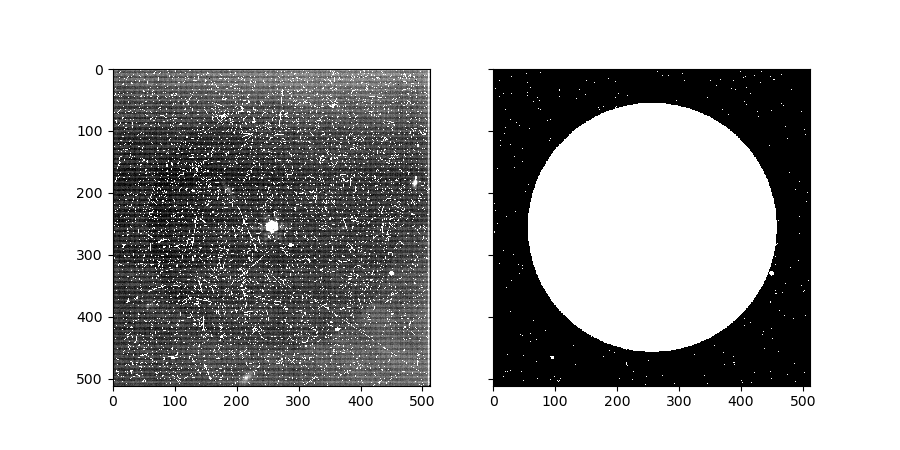

(<Figure size 900x450 with 2 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [47]:
#ds9_comp([im[1].data for im in fitsfiles])#comprehension
ds9_comp([np.sum([im[1].data[0] for im in fitsfiles], axis=0), 
         fitsfiles[10][1].data[3]])#comprehension

In [50]:
fitsfiles[10][1].data[0][250]

array([66.75068 , 67.87521 , 67.037445, 67.615425, 68.19742 , 68.11134 ,
       67.34448 ,       nan, 67.40049 , 67.65532 , 66.80346 , 67.07911 ,
       67.391754, 66.96107 , 67.41192 , 66.23134 , 68.158905, 68.87242 ,
       65.28148 , 66.501686, 67.08852 , 66.62515 , 65.78373 , 69.20603 ,
       66.86351 , 66.92697 , 66.24847 , 66.32562 , 66.83141 , 66.67823 ,
       66.71916 , 67.152145, 67.7273  , 67.49175 , 66.97367 , 68.74979 ,
       66.89931 , 66.0956  , 68.21409 , 68.224045, 68.026596, 67.74603 ,
       66.97649 , 67.42345 , 68.300064, 67.53027 , 68.038155, 67.8812  ,
       67.995224, 67.22558 , 66.87425 , 67.67562 , 67.4811  , 67.74111 ,
       67.40844 , 66.17466 , 67.74838 , 65.89069 , 66.25136 , 66.52597 ,
       68.098114, 65.69893 , 67.47914 , 68.301414, 67.41746 , 66.43284 ,
       68.521545, 67.895294, 66.98565 , 68.17716 , 66.543686, 68.55963 ,
       66.86004 , 67.79972 , 67.409584, 67.95952 , 65.75777 , 65.66269 ,
       67.552864, 66.03756 , 66.54377 , 67.43996 , 

In [10]:
import pandas as pd
# hk is a dictionary of extensions and header keys
def get_pandas_header(fs, hk={0:['FILTER','OBJECT']}):
    dic={}
    for ext in hk.keys():
        for k in hk[ext]:
            dic[k]= [f[ext].header[k] for f in fs]
    return pd.DataFrame(dic)

In [11]:
df = get_pandas_header(fitsfiles, {0:['TARG_RA','TARG_DEC','FILTER','EXPSTART','EXPEND','EFFEXPTM', 'DETECTOR'],
                                  1: ['CRVAL1', 'CRVAL2']})

df.sort_values('EXPSTART')   # archivos apuntando al mismo lado

# es más tiempo que lo que el paper dice que debería ser
# la diferencia entre el tiempo inicial y final no calza

,TARG_RA,TARG_DEC,FILTER,EXPSTART,EXPEND,EFFEXPTM,DETECTOR,CRVAL1,CRVAL2
0,346.628571,-5.04458,F1500W,60270.825218,60272.425155,138234.537,MIRIMAGE,346.628529,-5.044605
50,346.628571,-5.04458,F1500W,60270.825218,60272.425155,138234.537,MIRIMAGE,346.628529,-5.044605
49,346.628571,-5.04458,F1500W,60270.825218,60272.425155,138234.537,MIRIMAGE,346.628529,-5.044605
48,346.628571,-5.04458,F1500W,60270.825218,60272.425155,138234.537,MIRIMAGE,346.628529,-5.044605
47,346.628571,-5.04458,F1500W,60270.825218,60272.425155,138234.537,MIRIMAGE,346.628529,-5.044605
...,...,...,...,...,...,...,...,...,...
83,346.628572,-5.04458,F1500W,60272.429362,60273.287601,74151.900,MIRIMAGE,346.628527,-5.044603
84,346.628572,-5.04458,F1500W,60272.429362,60273.287601,74151.900,MIRIMAGE,346.628527,-5.044603
85,346.628572,-5.04458,F1500W,60272.429362,60273.287601,74151.900,MIRIMAGE,346.628527,-5.044603
78,346.628572,-5.04458,F1500W,60272.429362,60273.287601,74151.900,MIRIMAGE,346.628527,-5.044603


1 2


<IPython.core.display.Javascript object>


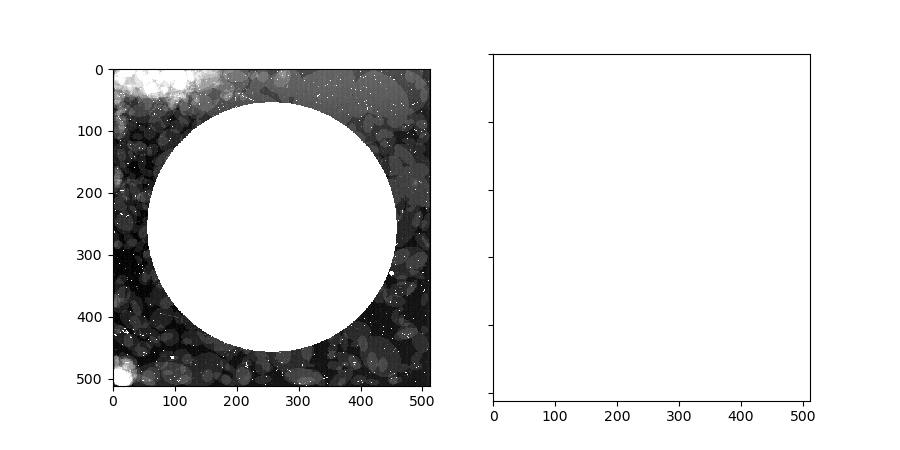

1 2


<IPython.core.display.Javascript object>


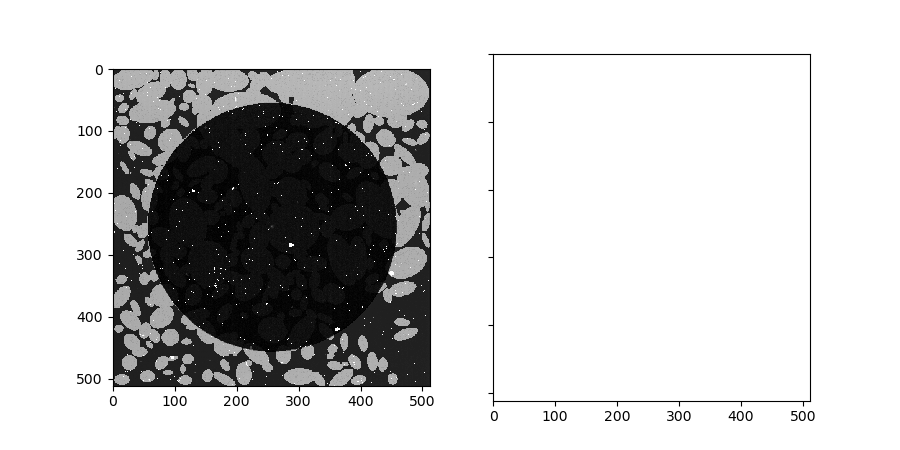

(<Figure size 900x450 with 2 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [12]:
#ds9_comp(fitsfiles[0][1].data,ncols=7)
ds9_comp([np.sum(fitsfiles[15][2].data,axis=0)])
ds9_comp([fitsfiles[15][2].data[0]])

10 5


<IPython.core.display.Javascript object>


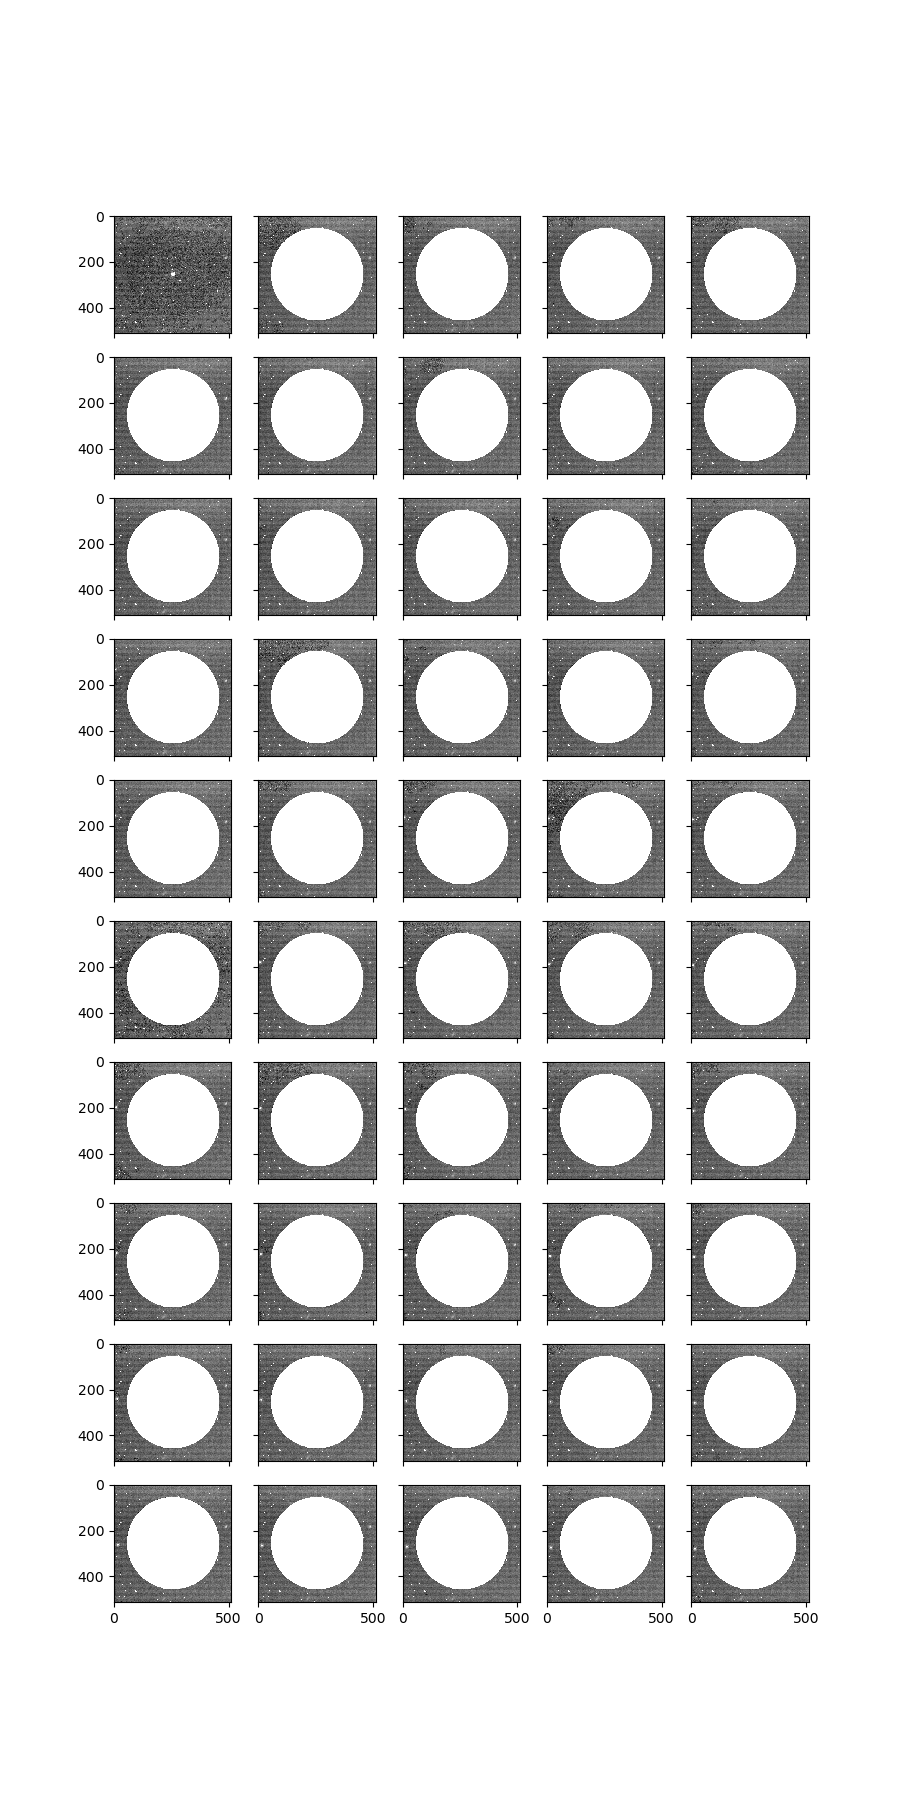

(<Figure size 900x1800 with 50 Axes>,
 array([[<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>

In [13]:
ds9_comp(fitsfiles[70][1].data,ncols=5)
#ds9_comp([np.sum(fitsfiles[70][1].data,axis=0)])

In [14]:
# funcion para encontrar indices de los archivos que apuntan hacia el mismo lado

def obs_idx(data, sort_by, first, last):
    # data: df a ocupar
    # sort_by: el parámetro en el que se ordena df (str)
    # first, last: primer y último archivo buscado
    return np.array(data.sort_values(sort_by).index[first:last])

In [15]:
obsidx_1 = obs_idx(df,'EXPSTART',0,70)
obsidx_2 = obs_idx(df,'EXPSTART',70,108)

In [16]:
# funcion para hacer la suma con todos los monos

def array_for_sum(idx_list,im):
    diff_length = []
    same_length = []
    
    for i in idx_list:
        if len(fitsfiles[i][1].data) != im:
            diff_length.append(i)
        else:
            same_length.append(i)
    
    added_array = fitsfiles[same_length[0]][1].data
    for s in same_length:
        added_array = np.add(added_array,fitsfiles[s][1].data)
    for d in diff_length:
        for j in range(len(fitsfiles[d][1].data)):
            added_array = np.add(added_array,fitsfiles[d][1].data[j])
        
    return added_array

In [17]:
obs_1_func = array_for_sum(obsidx_1,50)
obs_2_func = array_for_sum(obsidx_2,50)

In [18]:
sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()

bkg_1 = Background2D(np.sum(obs_1_func,axis=0), (8, 8), filter_size=(3, 3),
                   sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
bkg_2 = Background2D(np.sum(obs_2_func,axis=0), (8, 8), filter_size=(3, 3),
                   sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)

In [19]:
sin_bkg_1 = np.sum(obs_1_func,axis=0) - bkg_1.background
sin_bkg_2 = np.sum(obs_2_func,axis=0) - bkg_2.background

1 2


<IPython.core.display.Javascript object>


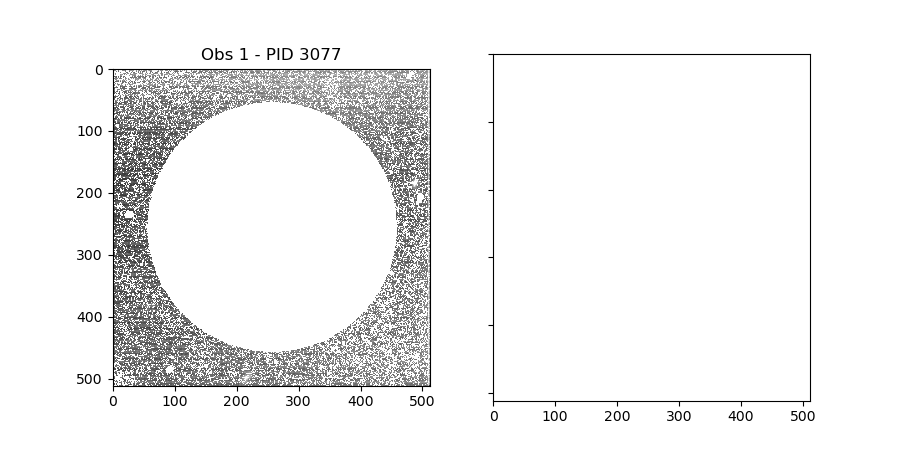

1 2


<IPython.core.display.Javascript object>


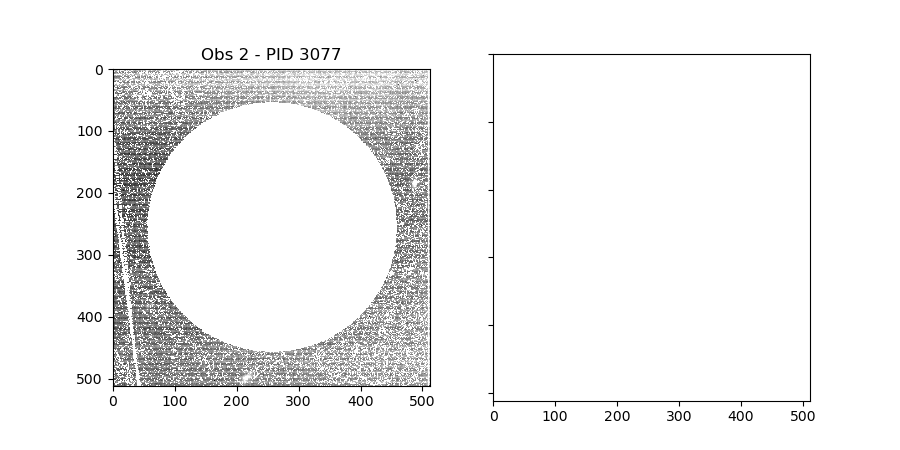

Text(0.5, 1.0, 'Obs 2 - PID 3077')

In [23]:
fig1, axis1 = ds9_comp([np.sum(obs_1_func,axis=0)])
fig2, axis2 = ds9_comp([np.sum(obs_2_func,axis=0)])

axis1[0].set_title('Obs 1 - PID 3077')
axis2[0].set_title('Obs 2 - PID 3077')

Como sale chistoso, intentar cólo con el dato 0

In [22]:
# funcion para hacer la suma con todos los monos

def array_for_image(idx_list,im,dataidx):
    diff_length = []
    same_length = []
    
    for i in idx_list:
        if len(fitsfiles[i][1].data) != im:
            diff_length.append(i)
        else:
            same_length.append(i)
    
    added_array = fitsfiles[same_length[0]][1].data[dataidx]
    for s in same_length:
        added_array = np.add(added_array,fitsfiles[s][1].data[dataidx])
    for d in diff_length:
        added_array = np.add(added_array,fitsfiles[d][1].data[dataidx])
        
    return added_array

In [23]:
obs_1_func = array_for_image(obsidx_1,50,0)
obs_2_func = array_for_image(obsidx_2,50,0)

1 2


<IPython.core.display.Javascript object>


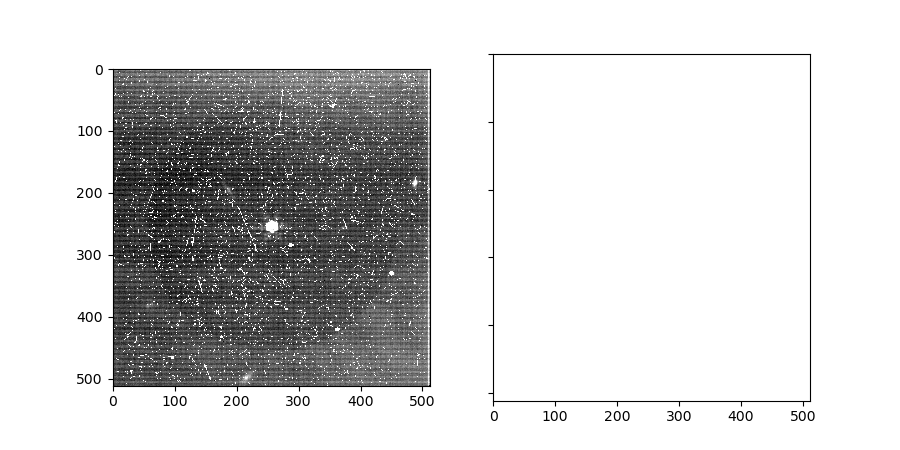

1 2


<IPython.core.display.Javascript object>


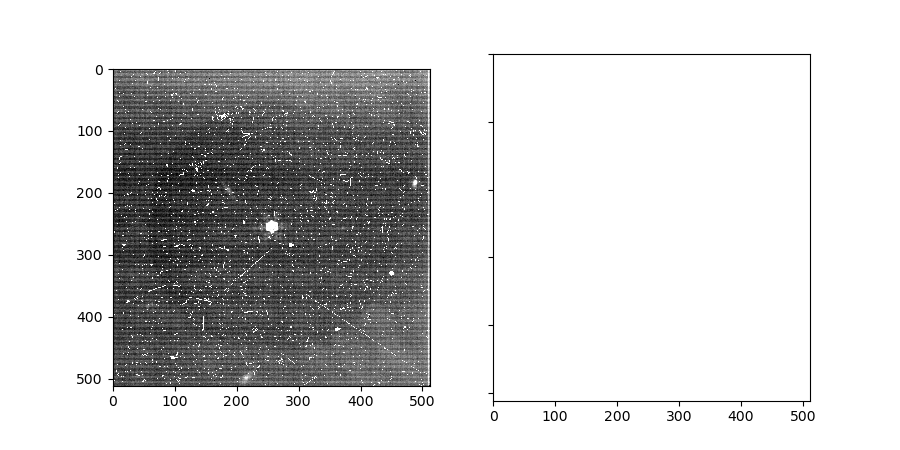

(<Figure size 900x450 with 2 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [24]:
ds9_comp([obs_1_func])
ds9_comp([obs_2_func])

In [25]:
sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()

bkg_1 = Background2D(obs_1_func, (8, 8), filter_size=(3, 3),
                   sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
bkg_2 = Background2D(obs_2_func, (8, 8), filter_size=(3, 3),
                   sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)

In [26]:
sin_bkg_1 = obs_1_func - bkg_1.background
sin_bkg_2 = obs_2_func - bkg_2.background

1 2


<IPython.core.display.Javascript object>


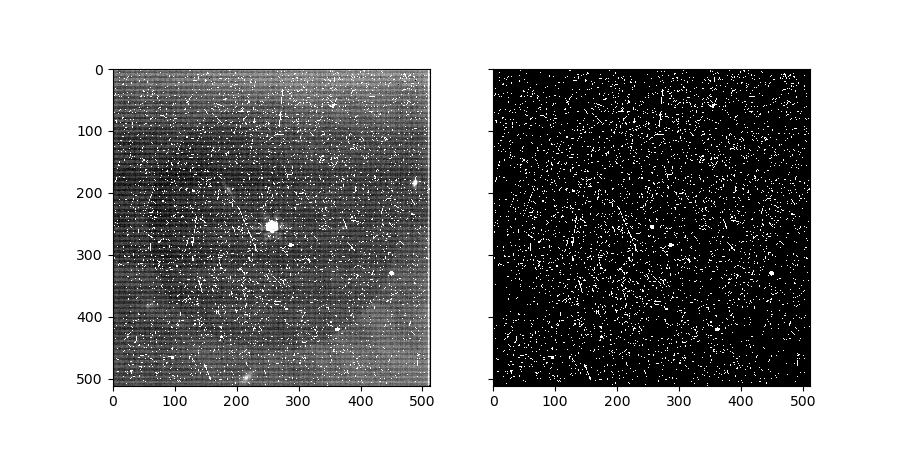

1 2


<IPython.core.display.Javascript object>


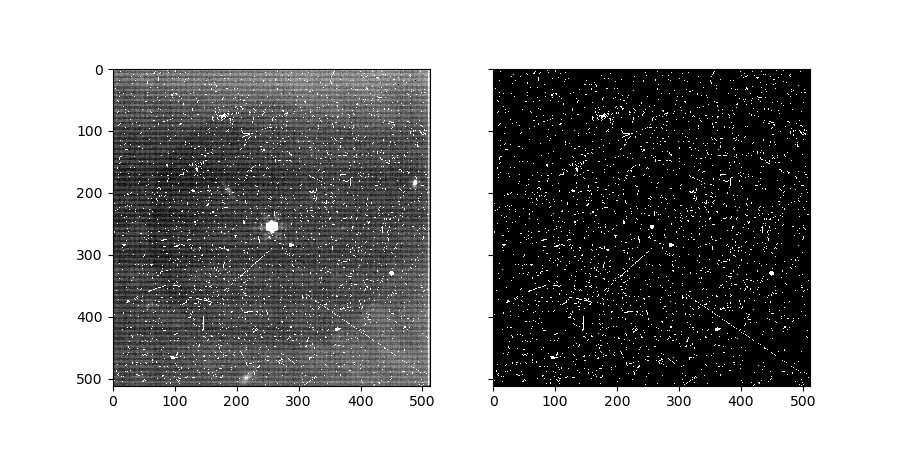

(<Figure size 900x450 with 2 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [27]:
ds9_comp([obs_1_func,sin_bkg_1])
ds9_comp([obs_2_func,sin_bkg_2])